In [1]:
import sys
sys.path.append("../utils/py")

import miniramses as ram

In [2]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import argparse
import miniramses as ram

prefix = 'grav'
path = '/home/jl4415/mini-ramses/'
nout = '4'

center=np.array([600,600,600])
log0=None

if prefix==None:
    prefix="hydro"
if path==None:
    path="./"
else:
    path=path+"/"
if prefix=="hydro":
    isort=0
if prefix=="peak":
    isort=1
if prefix=="grav":
    isort=0
if prefix=="rt":
    isort=0

print("Reading output number ",nout)


def compare(nout, nout_base, cen = 600, width = 10, grid=True):
    nout = str(nout)
    nout_base = str(nout_base)
    c=ram.rd_cell(nout,path=path,prefix=prefix,center=center)
    i=ram.rd_info(nout,path=path)
    c_base=ram.rd_cell(nout_base,path=path,prefix=prefix,center=center)
    i_base=ram.rd_info(nout_base,path=path)
    ii=1; jj=2
    mask = np.abs(c.x[2] - cen)<width
    if grid:
        ram.visu(c.x[0][mask],c.x[1][mask],c.dx[mask],c.g[0][mask]-c_base.g[0][mask],sort=c.g[0][mask]-c_base.g[0][mask], cmap='magma', grid=grid)
    else:
        ram.visu(c.x[0][mask],c.x[1][mask],c.dx[mask],c.g[0][mask]-c_base.g[0][mask],sort=c.g[0][mask]-c_base.g[0][mask], cmap='magma')
       
    print(np.median((c.g[0][mask]-c_base.g[0][mask])/c_base.g[0][mask]))
    print(np.log(np.sum(np.array(c.level)==7)/8 + np.sum(np.array(c.level)==6))/np.log(2))
    return c.g[0][mask]-c_base.g[0][mask]
    
def plot(nout, cen = 600, width = 10, grid=True):
    ii=1; jj=2
    nout = str(nout)
    c=ram.rd_cell(nout,path=path,prefix=prefix,center=center)
    i=ram.rd_info(nout,path=path)
    mask = np.abs(c.x[2] - cen)<width
    print("UNIQUE LEVELS: ", np.unique(c.level))
    try:
        if grid:
            ram.visu(c.x[0][mask],c.x[1][mask],c.dx[mask],c.g[0][mask],sort=c.g[0][mask], cmap='magma', grid=grid)
        else:
            ram.visu(c.x[0][mask],c.x[1][mask],c.dx[mask],c.g[0][mask],sort=c.g[0][mask], cmap='magma')
    except Exception as e:
        print(e)

    return c

Reading output number  4


In [3]:
#nout =  '3'  # fmm (7,8)
#nout =  '4'  # multgrid  (7,8)
#nout =  '5'  # multigrid (8,8)
#nout =  '6'  # fmm (8,8)

ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
min= 0.0  max= 0.0
0.0
18.0


array([0., 0., 0., ..., 0., 0., 0.])

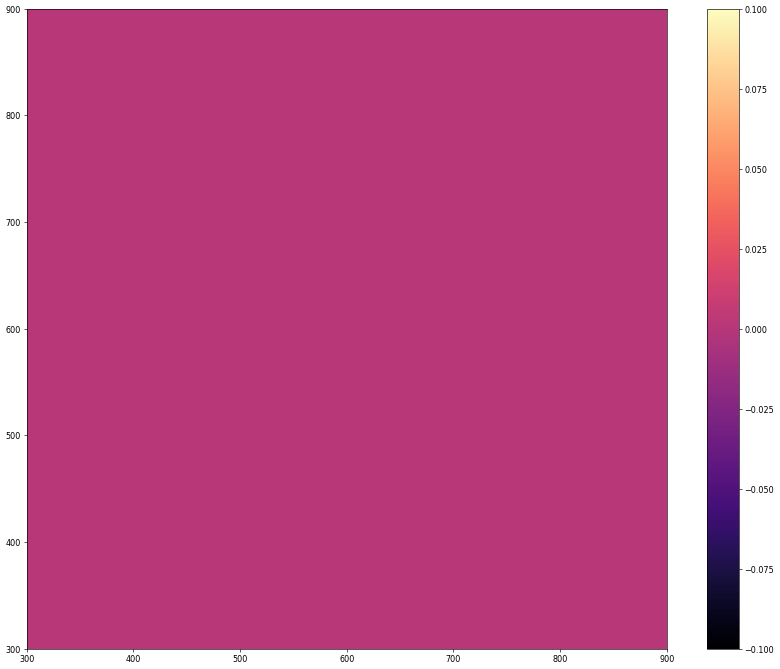

In [7]:
compare(3,2, 600, 5, False)
#mk_image // project

ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097152 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097152 leaf cells
Extracting leaf cells...
min= -5267.96875  max= 71.765625
0.00045116422889687383
18.0


array([ 15.4296875 ,   4.30859375,   2.0546875 , ..., -48.17578125,
       -48.57226562, -55.1875    ])

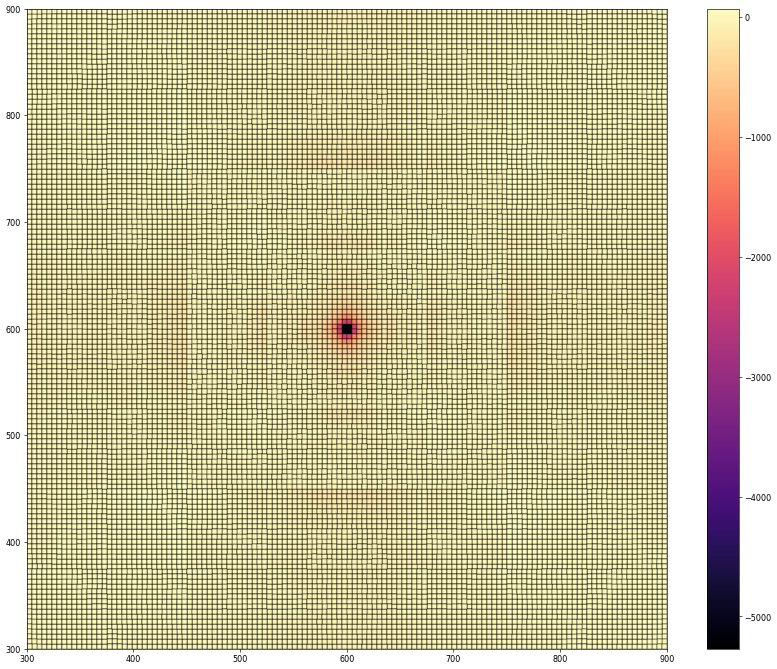

In [36]:
compare(5,6, 600, 5)

ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
UNIQUE LEVELS:  [6 7]
min= -121564.234375  max= -13233.46484375


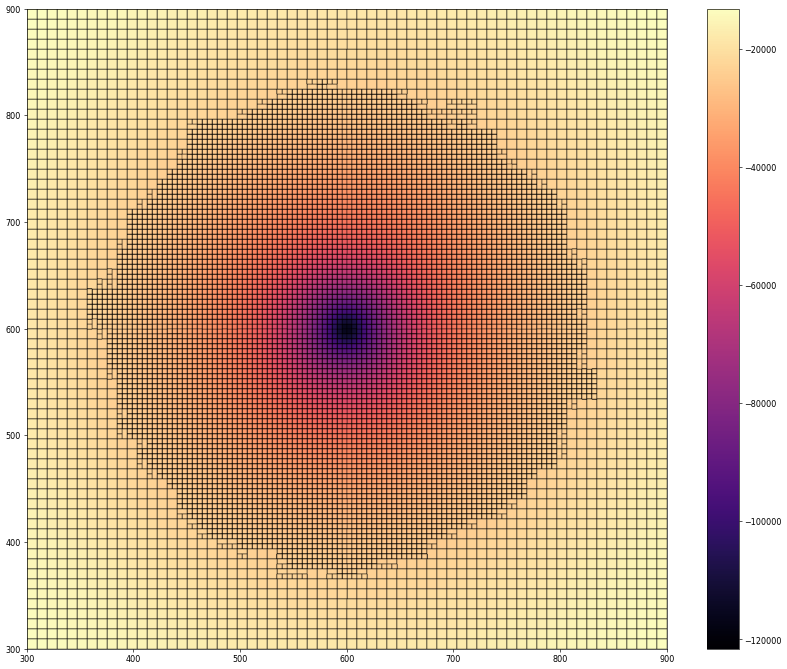

In [33]:
plot(3, 600, 10, True)

In [7]:
plot(3, False)

ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
UNIQUE LEVELS:  [6 7]


In [8]:
#mg
'''
     seconds         %    STEP
       0.127       1.0    refine                  
       2.844      21.4    rho                     
       7.502      56.4    poisson                 
       2.797      21.0    particle - kickdrift    
       0.030       0.2    time step               
      13.300     100.0    TOTAL
'''

'\n     seconds         %    STEP\n       0.127       1.0    refine                  \n       2.844      21.4    rho                     \n       7.502      56.4    poisson                 \n       2.797      21.0    particle - kickdrift    \n       0.030       0.2    time step               \n      13.300     100.0    TOTAL\n'

In [9]:
#fmm

'''
     seconds         %    STEP
       0.066       0.5    refine                  
       2.922      22.1    rho                     
       8.233      62.2    poisson                 
       0.125       0.9    grav force              
       1.846      13.9    particle - kickdrift    
       0.032       0.2    time step               
       0.024       0.2    recursive call          
      13.246     100.0    TOTAL
'''

'\n     seconds         %    STEP\n       0.066       0.5    refine                  \n       2.922      22.1    rho                     \n       8.233      62.2    poisson                 \n       0.125       0.9    grav force              \n       1.846      13.9    particle - kickdrift    \n       0.032       0.2    time step               \n       0.024       0.2    recursive call          \n      13.246     100.0    TOTAL\n'

ncpu=1 ndim=3 nlevelmax=9
Time= 0.102467374407592
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097208 leaf cells
Extracting leaf cells...
UNIQUE LEVELS:  [7 8]
min= -0.25971388816833496  max= -0.02511351928114891


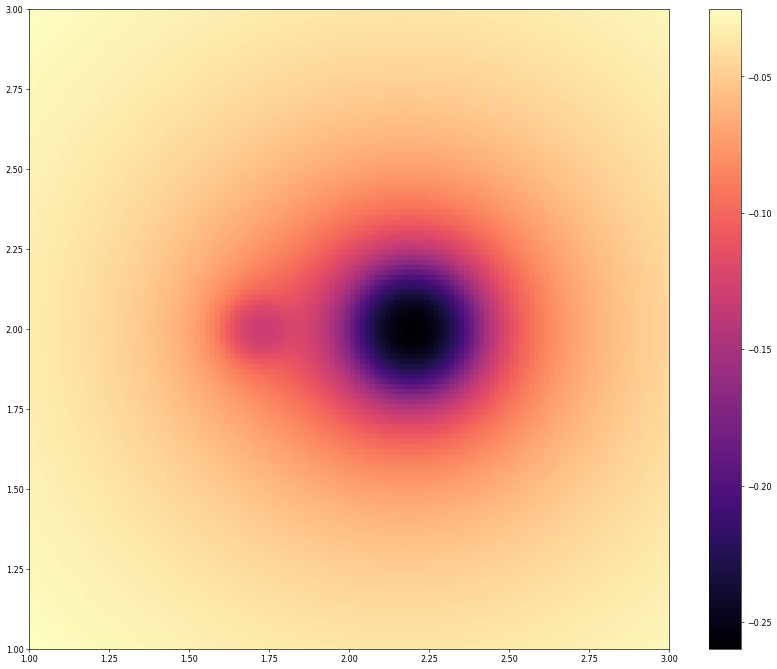

In [12]:
plot(13, 2, 0.01, False)

ncpu=1 ndim=3 nlevelmax=9
Time= 0.102467374407592
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097208 leaf cells
Extracting leaf cells...
ncpu=1 ndim=3 nlevelmax=9
Time= 0.103960080008642
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 2097208 leaf cells
Extracting leaf cells...
min= -0.0009692981839179993  max= 0.0006751567125320435
0.0008832229634223266
17.999994496544677


array([-2.71201134e-05, -1.49980187e-05, -2.99811363e-05, ...,
        3.66482884e-04,  3.69172543e-04,  4.12270427e-04])

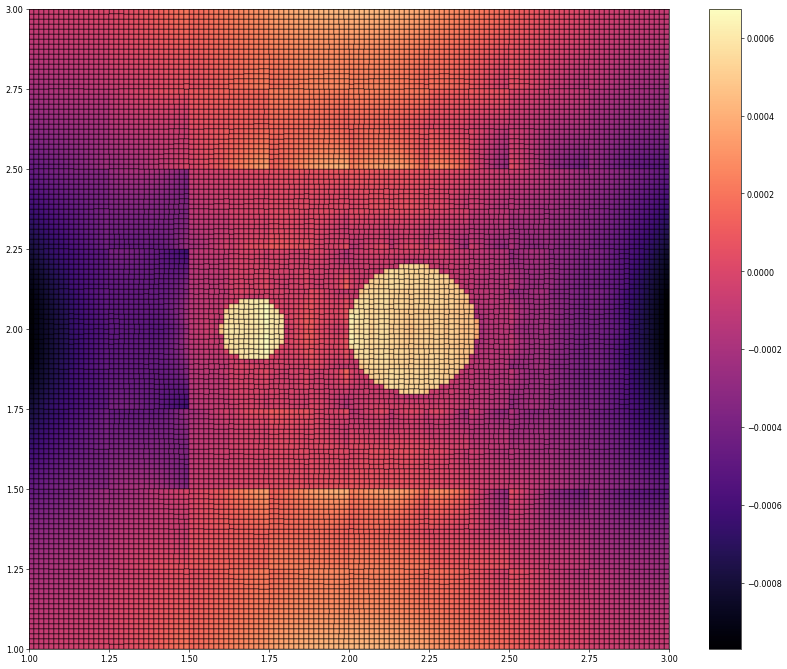

In [20]:
compare(13, 14, 2, 0.01, True)

ncpu=1 ndim=3 nlevelmax=8
Time= 0.00509681502068084
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 688283 leaf cells
Extracting leaf cells...
UNIQUE LEVELS:  [6 7]
min= -121564.234375  max= -13233.46484375


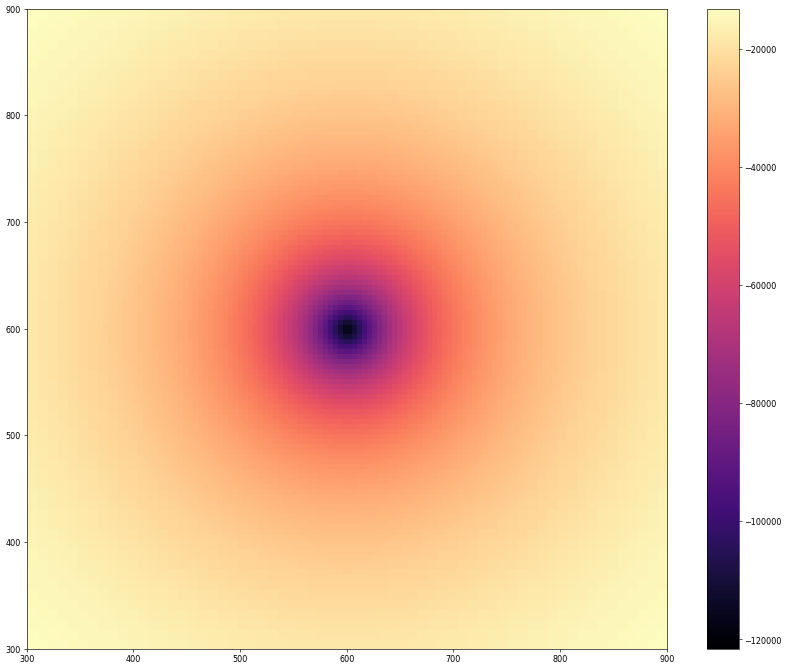

In [30]:
plot(2, 600, 10, False)